In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "DATA" / "PROCESSED"

CLEAN_FILE = PROCESSED_DIR / "cars_clean.csv"

print(CLEAN_FILE)

C:\Users\sitar\Downloads\ASSIGNMENT_CODE\CARS\DATA\PROCESSED\cars_clean.csv


In [3]:
cars = pd.read_csv(CLEAN_FILE)

print("Shape:", cars.shape)
cars.head()

Shape: (1725, 9)


,id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city
0,0,2016,Honda,Honda Brio S MT,Brio,425000.0,9680.0,Petrol,Mumbai
1,1,2012,Nissan,Nissan Sunny XV Diesel,Sunny,325000.0,119120.0,Diesel,Mumbai
2,2,2017,Toyota,Toyota Fortuner 2.8 4x2 MT [2016-2020],Fortuner,2650000.0,64593.0,Diesel,Thane
3,3,2017,Mercedes-Benz,Mercedes-Benz E-Class E 220d Expression [2019-...,E-Class,4195000.0,25000.0,Diesel,Mumbai
4,4,2012,Hyundai,Hyundai Verna Fluidic 1.6 CRDi SX,Verna,475000.0,23800.0,Diesel,Mumbai


In [4]:
print("Rows:", len(cars))
print("Columns:", len(cars.columns))

print("\nColumns:")
print(cars.columns.tolist())

Rows: 1725
Columns: 9

Columns:
['id', 'year', 'brand', 'full_model_name', 'model_name', 'price', 'distance_travelled(kms)', 'fuel_type', 'city']


In [5]:
cars.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1725.0,8.620000e+02,4.981089e+02,0.0,431.0,862.0,1293.0,1724.0
year,1725.0,2.015391e+03,3.207504e+00,1990.0,2013.0,2016.0,2018.0,2021.0
price,1725.0,1.494837e+06,1.671658e+06,62500.0,545000.0,875000.0,1825000.0,14700000.0
distance_travelled(kms),1725.0,5.384826e+04,4.472554e+04,350.0,29000.0,49000.0,70500.0,790000.0


In [6]:
brand_columns = [
    col for col in cars.columns
    if col in ["brand", "make", "manufacturer"]
]

print("Possible brand columns:", brand_columns)

Possible brand columns: ['brand']


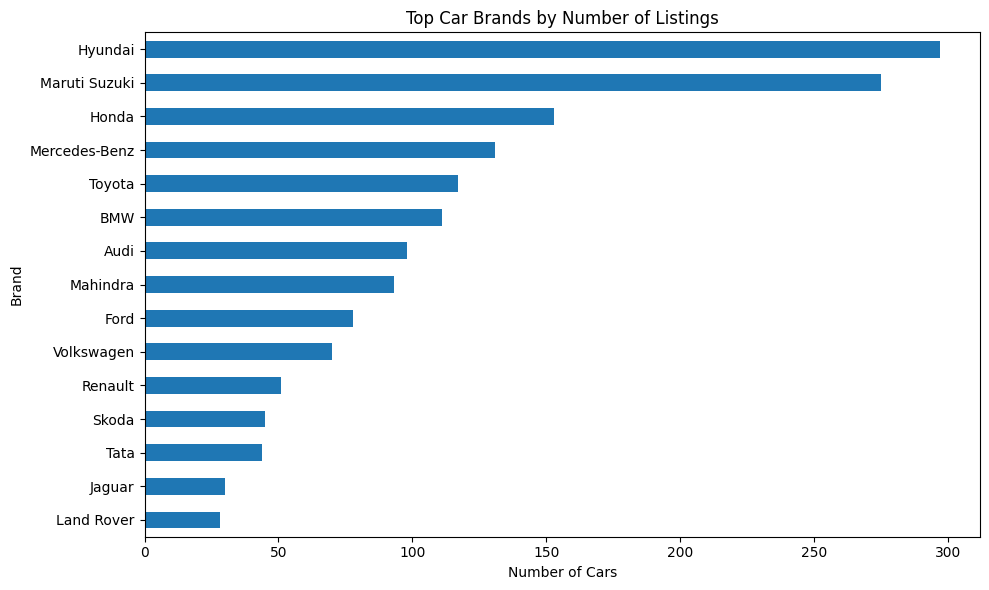

In [7]:
if brand_columns:
    brand_col = brand_columns[0]

    brand_counts = cars[brand_col].value_counts().head(15)

    plt.figure(figsize=(10, 6))
    brand_counts.sort_values().plot(kind="barh")
    plt.title("Top Car Brands by Number of Listings")
    plt.xlabel("Number of Cars")
    plt.ylabel("Brand")
    plt.tight_layout()
    plt.show()
else:
    print("No standard brand column found.")

In [8]:
price_candidates = [
    "selling_price",
    "price",
    "resale_price"
]

price_columns = [
    col for col in price_candidates
    if col in cars.columns
]

print("Price columns found:", price_columns)

Price columns found: ['price']


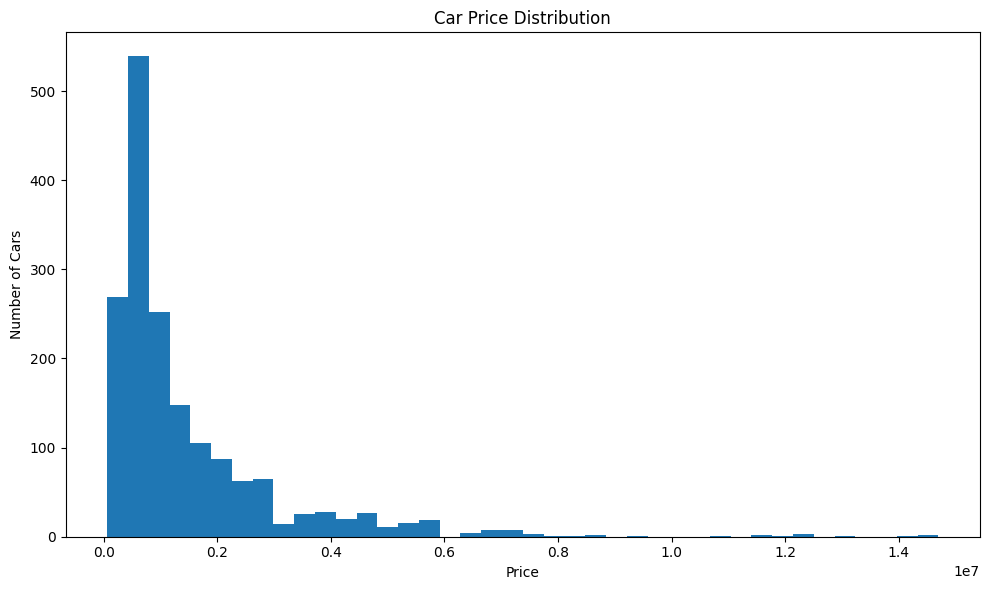

In [9]:
if price_columns:
    PRICE_COL = price_columns[0]

    plt.figure(figsize=(10, 6))
    plt.hist(cars[PRICE_COL], bins=40)
    plt.title("Car Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Number of Cars")
    plt.tight_layout()
    plt.show()
else:
    raise ValueError("No price column found.")

In [10]:
print("Minimum price:", cars[PRICE_COL].min())
print("Maximum price:", cars[PRICE_COL].max())
print("Average price:", cars[PRICE_COL].mean())
print("Median price:", cars[PRICE_COL].median())

Minimum price: 62500.0
Maximum price: 14700000.0
Average price: 1494837.391304348
Median price: 875000.0


In [11]:
fuel_candidates = ["fuel", "fuel_type"]

fuel_columns = [
    col for col in fuel_candidates
    if col in cars.columns
]

print(fuel_columns)

['fuel_type']


fuel_type
Diesel        922
Petrol        788
CNG + 1         8
Petrol + 1      6
Hybrid          1
Name: count, dtype: int64


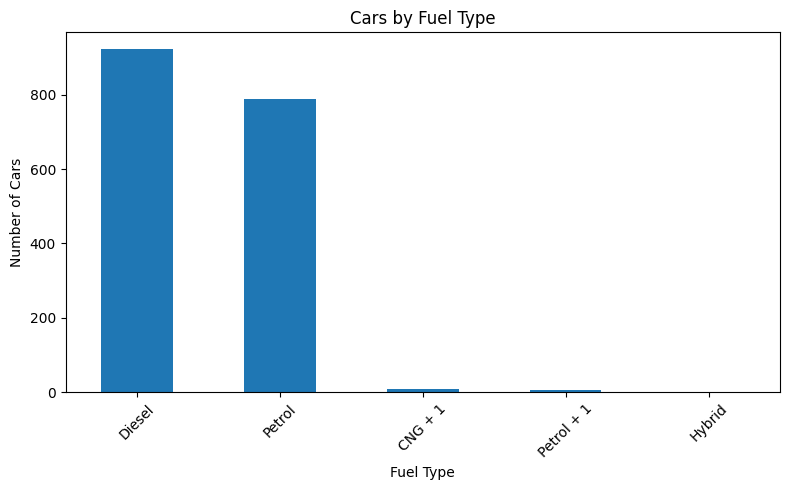

In [12]:
if fuel_columns:
    FUEL_COL = fuel_columns[0]

    print(cars[FUEL_COL].value_counts())

    plt.figure(figsize=(8, 5))
    cars[FUEL_COL].value_counts().plot(kind="bar")
    plt.title("Cars by Fuel Type")
    plt.xlabel("Fuel Type")
    plt.ylabel("Number of Cars")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
if "transmission" in cars.columns:

    print(cars["transmission"].value_counts())

    plt.figure(figsize=(8, 5))
    cars["transmission"].value_counts().plot(kind="bar")
    plt.title("Cars by Transmission")
    plt.xlabel("Transmission")
    plt.ylabel("Number of Cars")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

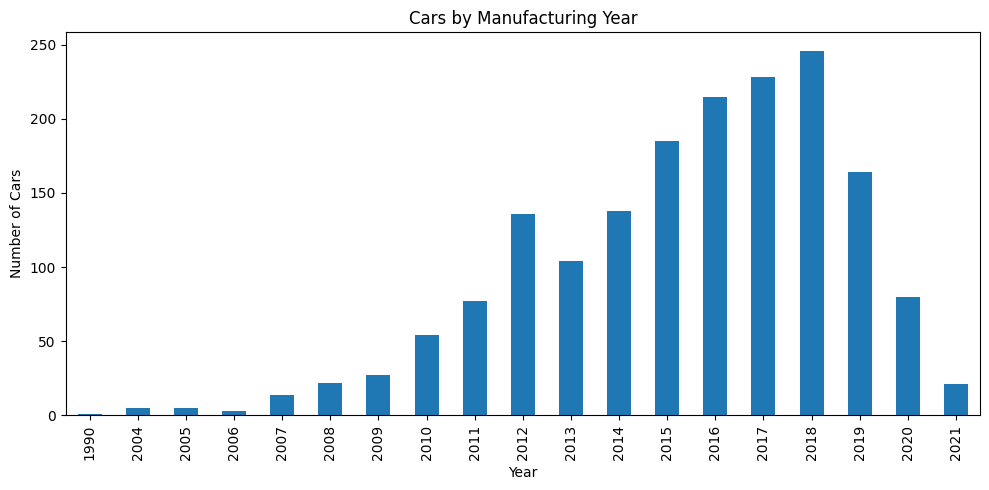

In [14]:
if "year" in cars.columns:

    plt.figure(figsize=(10, 5))
    cars["year"].value_counts().sort_index().plot(kind="bar")
    plt.title("Cars by Manufacturing Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Cars")
    plt.tight_layout()
    plt.show()

In [15]:
km_candidates = [
    "km_driven",
    "kilometers_driven",
    "distance_travelled"
]

km_columns = [
    col for col in km_candidates
    if col in cars.columns
]

print(km_columns)

[]


In [16]:
if km_columns:

    KM_COL = km_columns[0]

    plt.figure(figsize=(10, 6))
    plt.scatter(
        cars[KM_COL],
        cars[PRICE_COL],
        alpha=0.4
    )

    plt.title("Kilometers Driven vs Car Price")
    plt.xlabel("Kilometers Driven")
    plt.ylabel("Price")
    plt.tight_layout()
    plt.show()

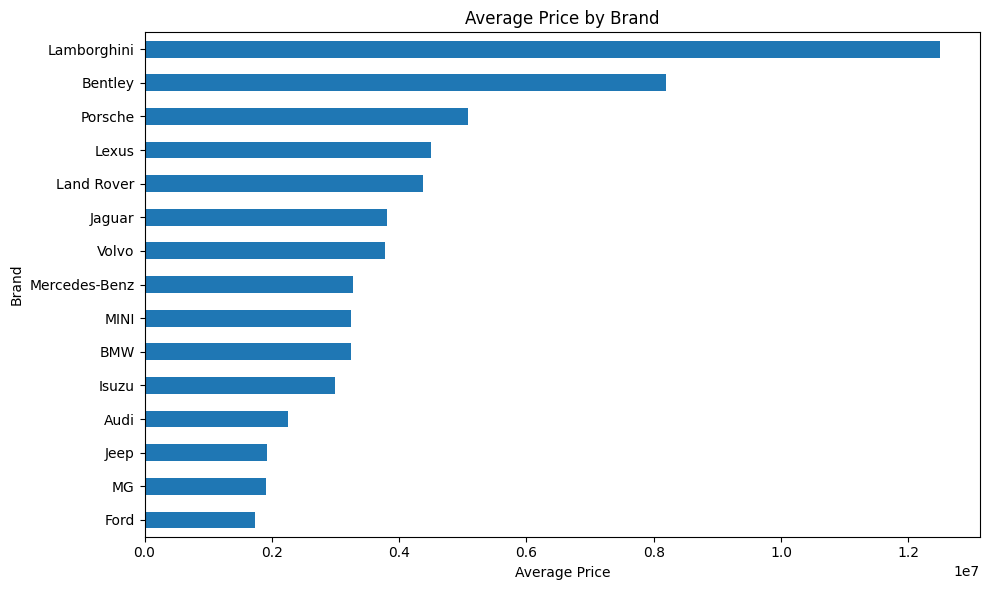

In [17]:
if brand_columns:

    brand_price = (
        cars.groupby(brand_col)[PRICE_COL]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10, 6))
    brand_price.sort_values().plot(kind="barh")

    plt.title("Average Price by Brand")
    plt.xlabel("Average Price")
    plt.ylabel("Brand")

    plt.tight_layout()
    plt.show()

In [18]:
numeric_data = cars.select_dtypes(include=np.number)

correlation = numeric_data.corr()

correlation

,id,year,price,distance_travelled(kms)
id,1.000000,-0.054391,-0.105696,0.100282
year,-0.054391,1.000000,0.288483,-0.386107
price,-0.105696,0.288483,1.000000,-0.137351
distance_travelled(kms),0.100282,-0.386107,-0.137351,1.000000


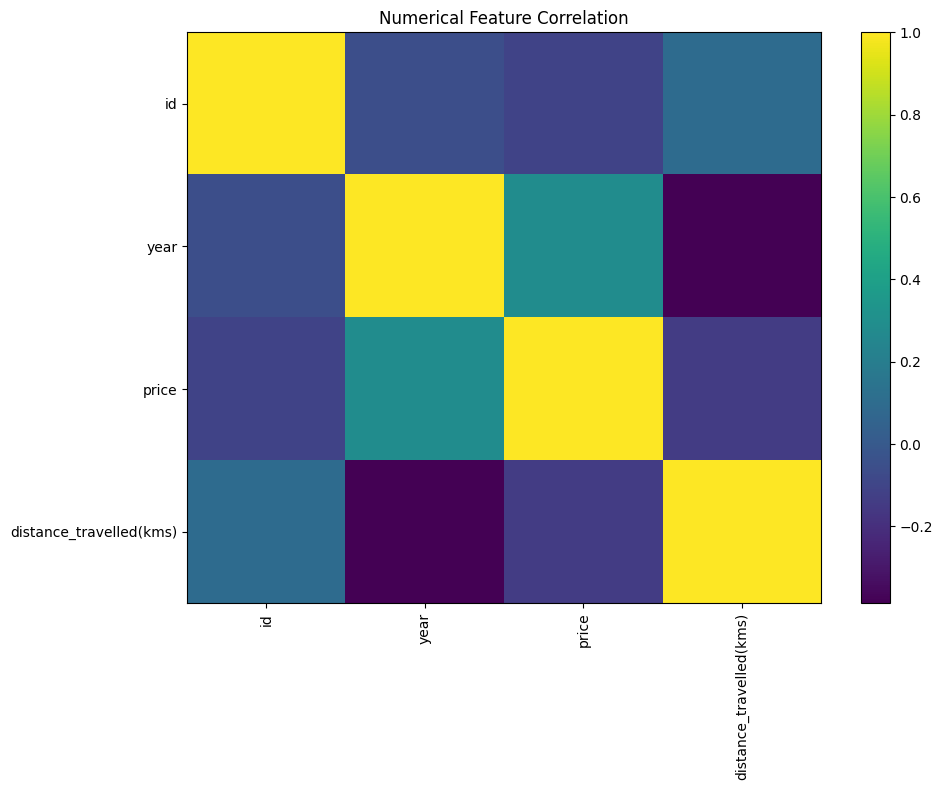

In [19]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Numerical Feature Correlation")

plt.tight_layout()
plt.show()

In [20]:
print("========== MARKET SUMMARY ==========")

print("Total cars:", len(cars))

if brand_columns:
    print("Number of brands:", cars[brand_col].nunique())

if fuel_columns:
    print("Fuel types:", cars[FUEL_COL].nunique())

if "transmission" in cars.columns:
    print("Transmission types:", cars["transmission"].nunique())

print("Average price:", round(cars[PRICE_COL].mean(), 2))
print("Median price:", round(cars[PRICE_COL].median(), 2))

========== MARKET SUMMARY ==========
Total cars: 1725
Number of brands: 31
Fuel types: 5
Average price: 1494837.39
Median price: 875000.0
